<a href="https://colab.research.google.com/github/Koji-Accounting-Tech/D365-Finance-Data-Validator/blob/main/D365_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Excelファイルの読み込み
df = pd.read_excel('test_data.xlsx')

# 2. データの先頭5行を表示して中身を確認
print("--- データの先頭5行 ---")
display(df.head())

# 3. 基本的な統計量（件数、合計、平均など）を表示
print("\n--- データの統計情報 ---")
display(df.describe())

--- データの先頭5行 ---


,伝票番号,日付,勘定科目コード,借方金額,貸方金額,摘要
0,1,2026-04-01,100501,100000,100000,備品
1,2,2026-04-01,100601,200000,200000,買掛金支払
2,3,2026-04-01,100701,300000,300000,売掛金入金
3,4,2026-04-02,100802,400000,400000,減価償却・設備
4,5,2026-04-02,200101,500000,500000,売上



--- データの統計情報 ---


,伝票番号,日付,勘定科目コード,借方金額,貸方金額
count,5.000000,5,5.000000,5.000000,5.000000
mean,3.000000,2026-04-01 09:36:00,120541.200000,300000.000000,300000.000000
min,1.000000,2026-04-01 00:00:00,100501.000000,100000.000000,100000.000000
25%,2.000000,2026-04-01 00:00:00,100601.000000,200000.000000,200000.000000
50%,3.000000,2026-04-01 00:00:00,100701.000000,300000.000000,300000.000000
75%,4.000000,2026-04-02 00:00:00,100802.000000,400000.000000,400000.000000
max,5.000000,2026-04-02 00:00:00,200101.000000,500000.000000,500000.000000
std,1.581139,NaN,44475.421642,158113.883008,158113.883008


In [ ]:
import pandas as pd

# 1. 旧システムのマスタ（移行元）
old_master = {
    '旧コード': ['100', '200', '300', '400'],
    '名称': ['現金', '普通預金', '売掛金', '支払利息']
}
df_old = pd.DataFrame(old_master)

# 2. 新システムのマスタ（移行先 / D365想定）
# ※ 3000番の名前が「未回収金」になっていたり、4000番が欠落していたりする想定
new_master = {
    '新コード': ['1000', '2000', '3000'],
    '名称': ['現金', '普通預金', '未回収金'] # '売掛金'ではなくなっている
}
df_new = pd.DataFrame(new_master)

# 3. 名称をキーにして外部結合（Outer Join）を行う
# indicator=True を使うと、どちらの表に存在するデータか一瞬でわかります
df_diff = pd.merge(df_old, df_new, on='名称', how='outer', indicator=True)

# 4. 差異（Diff）の分析
# 4-1. 新システムに移行漏れしている名称（旧にはあるが新にはない）
missing_in_new = df_diff[df_diff['_merge'] == 'left_only']

# 4-2. 名称が一致しない、またはコード変換が不明なもの
# 300番(売掛金)は、新システムでは「未回収金」になっているため、名称一致では紐付かない
# これを「名寄せが必要な候補」として抽出します

print("--- 新旧マスタ比較レポート ---")

if len(missing_in_new) > 0:
    print(f"⚠️ 移行漏れ・名称不一致の疑い: {len(missing_in_new)} 件")
    display(missing_in_new[['名称', '旧コード', '_merge']])

# 5. 【名寄せ・クレンジング】
# 類推やマッピング表を使って、新しい名称（未回収金）を「売掛金」に読み替える処理
# ここでは「名称の置換」を実演します
df_new['名称'] = df_new['名称'].replace('未回収金', '売掛金')

print("\n--- クレンジング実行後の再突合 ---")
df_cleaned = pd.merge(df_old, df_new, on='名称', how='inner')
display(df_cleaned)

--- 新旧マスタ比較レポート ---
⚠️ 移行漏れ・名称不一致の疑い: 2 件


,名称,旧コード,_merge
0,売掛金,300,left_only
1,支払利息,400,left_only



--- クレンジング実行後の再突合 ---


,旧コード,名称,新コード
0,100,現金,1000
1,200,普通預金,2000
2,300,売掛金,3000


In [ ]:
import pandas as pd

# 1. 採番データ（再定義）
seq_data = {
    '伝票番号': ['V001', 'V002', 'V004', 'V004', 'V005'],
    '金額': [100, 200, 400, 400, 500]
}
df_seq = pd.DataFrame(seq_data)

# 2. 数字部分を抽出
# ※ \d+ で数字を抜き出し、整数型に変換
df_seq['num'] = df_seq['伝票番号'].str.extract(r'(\d+)').astype(int)

# 3. 理想の連番リストを作成
# 最小値(1)から最大値(5)までの全ての数字を含んだ集合を作る
full_range = set(range(df_seq['num'].min(), df_seq['num'].max() + 1))

# 4. 実際のデータにある数字の集合
actual_nums = set(df_seq['num'])

# 5. 欠番の特定（引き算）
missing_nums = sorted(list(full_range - actual_nums))

print("\n--- 採番整合性レポート ---")

# 重複チェックの表示
duplicates = df_seq[df_seq.duplicated(subset=['伝票番号'], keep=False)]
if len(duplicates) > 0:
    print(f"🚫 重複エラー: 同じ伝票番号が {len(duplicates)} 件存在します。")
    display(duplicates[['伝票番号', '金額']])

# 欠番チェックの表示（ここを強化）
if missing_nums:
    print(f"⚠️ 欠番警告: 以下の番号がデータ内に存在しません。")
    for n in missing_nums:
        # V + 3桁ゼロ埋め形式に戻して表示
        print(f"  - V{n:03}")
else:
    print("✅ 番号の飛び（欠番）はありません。")


--- 採番整合性レポート ---
🚫 重複エラー: 同じ伝票番号が 2 件存在します。


,伝票番号,金額
2,V004,400
3,V004,400


⚠️ 欠番警告: 以下の番号がデータ内に存在しません。
  - V003


In [ ]:
import pandas as pd
import re

# 1. 不適切な文字を含んだ品目データ
# ※ 改行(\n)、タブ(\t)、アスタリスク(*)、アンパサンド(&)などが混入している想定
item_data = {
    '品目コード': ['ITM001', 'ITM002', 'ITM003', 'ITM004'],
    '品目名': [
        'Office Paper A4',
        'Keyboard\nWireless', # 改行が含まれている
        'Mouse &* Pad',       # & と * が含まれている
        'Laptop\tPro'         # タブが含まれている
    ]
}
df_item = pd.DataFrame(item_data)

# 2. クリーニング用の関数定義
def clean_special_characters(text):
    if not isinstance(text, str):
        return text

    # a. 改行、タブ、戻り（\n, \t, \r）を半角スペースに置換
    text = re.sub(r'[\n\t\r]', ' ', text)

    # b. D365で禁止・注意が必要な記号（* と &）をアンダースコアに置換
    # 業務ルールに合わせてここを書き換えます
    text = re.sub(r'[*&]', '_', text)

    # c. 連続したスペースを1つにまとめる（トリミング）
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# 3. クリーニングの実行
df_item['クリーニング後品目名'] = df_item['品目名'].apply(clean_special_characters)

# 4. 変更があった行だけを抽出して確認
df_changes = df_item[df_item['品目名'] != df_item['クリーニング後品目名']]

print("--- 特殊文字クリーニングレポート ---")
if len(df_changes) > 0:
    print(f"⚠️ 修正: 不適切な文字が含まれていたデータを {len(df_changes)} 件修正しました。")
    display(df_changes[['品目コード', '品目名', 'クリーニング後品目名']])
else:
    print("✅ クリーニングが必要な文字は見つかりませんでした。")

--- 特殊文字クリーニングレポート ---
⚠️ 修正: 不適切な文字が含まれていたデータを 3 件修正しました。


,品目コード,品目名,クリーニング後品目名
1,ITM002,Keyboard\nWireless,Keyboard Wireless
2,ITM003,Mouse &* Pad,Mouse __ Pad
3,ITM004,Laptop\tPro,Laptop Pro


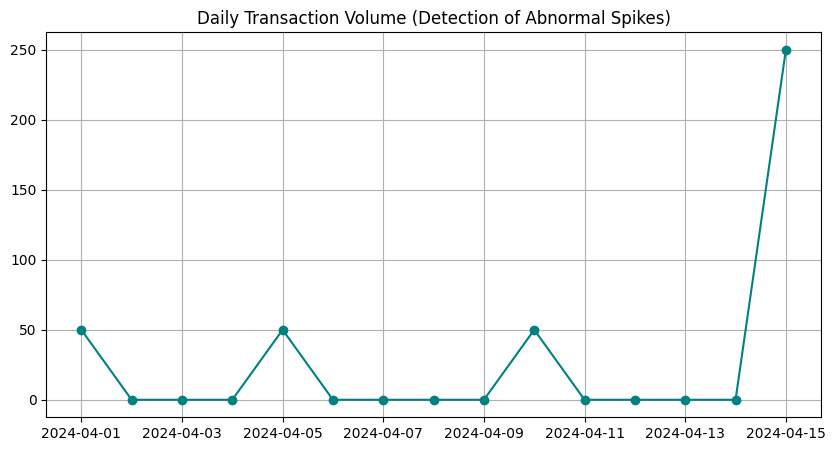

--- ボリューム分析結果 ---
🚩 異常検知: 2024-04-15 に最大件数 250 件が集中しています。


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 1ヶ月分の大量ログ（模擬データ）
# 4/15に異常なスパイク（山）がある想定
data = {
    '作成日時': pd.to_datetime(['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15']*50 + ['2024-04-15']*200),
    '伝票番号': range(400)
}
df_volume = pd.DataFrame(data)

# 2. 日次でカウントを集計
daily_trend = df_volume.set_index('作成日時').resample('D').count()

# 3. グラフ化して視覚的に特定
plt.figure(figsize=(10, 5))
plt.plot(daily_trend.index, daily_trend['伝票番号'], marker='o', color='teal')
plt.title('Daily Transaction Volume (Detection of Abnormal Spikes)')
plt.grid(True)
plt.show()

print("--- ボリューム分析結果 ---")
peak_day = daily_trend['伝票番号'].idxmax()
print(f"🚩 異常検知: {peak_day.date()} に最大件数 {daily_trend['伝票番号'].max()} 件が集中しています。")

In [ ]:
# 1. サポートログのデータ（模擬）
log_data = {
    'ErrorCode': ['ERR001', 'ERR002', 'ERR001', 'ERR003', 'ERR001', 'ERR002', 'ERR004'],
    'Message': [
        'Posting failed: Account locked',
        'Tax calculation error',
        'Posting failed: Account locked',
        'Currency conversion timeout',
        'Posting failed: Account locked',
        'Tax calculation error',
        'Unknown system error'
    ],
    'Module': ['Finance', 'Tax', 'Finance', 'Global', 'Finance', 'Tax', 'System']
}
df_logs = pd.DataFrame(log_data)

# 2. エラーメッセージの頻度（出現回数）をカウント
error_counts = df_logs['Message'].value_counts().reset_index()
error_counts.columns = ['ErrorMessage', 'Count']

print("\n--- エラーパターン解析レポート ---")
display(error_counts)

# 3. 最も頻発しているエラーを特定
top_error = error_counts.iloc[0]
print(f"🔥 最優先調査対象: '{top_error['ErrorMessage']}' が {top_error['Count']} 件発生しています。")


--- エラーパターン解析レポート ---


,ErrorMessage,Count
0,Posting failed: Account locked,3
1,Tax calculation error,2
2,Currency conversion timeout,1
3,Unknown system error,1


🔥 最優先調査対象: 'Posting failed: Account locked' が 3 件発生しています。


In [ ]:
import pandas as pd

# 1. 散在しているエラーログ
log_data = {
    'LogID': ['L1', 'L2', 'L3', 'L4', 'L5', 'L6'],
    'Message': [
        'Connection to server timed out',
        'User Taro lacks Permission to post',
        'Validation failed: Date is out of range',
        'Network Timeout occurred during sync',
        'Permission denied for account 1101',
        'Syntax error in XML data'
    ]
}
df_logs = pd.DataFrame(log_data)

# 2. カテゴリー判定のロジック
def categorize_error(msg):
    msg = msg.lower() # 検索しやすくするために小文字に統一
    if 'timeout' in msg:
        return 'Network/Timeout'
    elif 'permission' in msg:
        return 'Security/Permission'
    elif 'validation' in msg:
        return 'Data/Validation'
    else:
        return 'Other/Unknown'

# 3. 新しい列「Category」を作成して適用
df_logs['Category'] = df_logs['Message'].apply(categorize_error)

# 4. カテゴリーごとの集計
summary = df_logs['Category'].value_counts().reset_index()
summary.columns = ['Category', 'Count']

print("--- エラーメッセージ自動分類レポート ---")
display(df_logs)

print("\n--- カテゴリー別集計結果 ---")
display(summary)

--- エラーメッセージ自動分類レポート ---


,LogID,Message,Category
0,L1,Connection to server timed out,Other/Unknown
1,L2,User Taro lacks Permission to post,Security/Permission
2,L3,Validation failed: Date is out of range,Data/Validation
3,L4,Network Timeout occurred during sync,Network/Timeout
4,L5,Permission denied for account 1101,Security/Permission
5,L6,Syntax error in XML data,Other/Unknown



--- カテゴリー別集計結果 ---


,Category,Count
0,Other/Unknown,2
1,Security/Permission,2
2,Data/Validation,1
3,Network/Timeout,1


In [ ]:
import pandas as pd

# 1. 散在しているエラーログ
log_data = {
    'LogID': ['L1', 'L2', 'L3', 'L4', 'L5', 'L6'],
    'Message': [
        'Connection to server timed out',
        'User Taro lacks Permission to post',
        'Validation failed: Date is out of range',
        'Network Timeout occurred during sync',
        'Permission denied for account 1101',
        'Syntax error in XML data'
    ]
}
df_logs = pd.DataFrame(log_data)

# 2. カテゴリー判定のロジック
def categorize_error(msg):
    msg = msg.lower()
    # 'timeout' も 'timed out' も両方カバーするために 'time' で判定
    if 'time' in msg:
        return 'Network/Timeout'
    elif 'permission' in msg or 'denied' in msg or 'lacks' in msg:
        return 'Security/Permission'
    elif 'validation' in msg:
        return 'Data/Validation'
    else:
        return 'Other/Unknown'

# 3. 新しい列「Category」を作成して適用
df_logs['Category'] = df_logs['Message'].apply(categorize_error)

# 4. カテゴリーごとの集計
summary = df_logs['Category'].value_counts().reset_index()
summary.columns = ['Category', 'Count']

print("--- エラーメッセージ自動分類レポート ---")
display(df_logs)

print("\n--- カテゴリー別集計結果 ---")
display(summary)

--- エラーメッセージ自動分類レポート ---


,LogID,Message,Category
0,L1,Connection to server timed out,Network/Timeout
1,L2,User Taro lacks Permission to post,Security/Permission
2,L3,Validation failed: Date is out of range,Data/Validation
3,L4,Network Timeout occurred during sync,Network/Timeout
4,L5,Permission denied for account 1101,Security/Permission
5,L6,Syntax error in XML data,Other/Unknown



--- カテゴリー別集計結果 ---


,Category,Count
0,Network/Timeout,2
1,Security/Permission,2
2,Data/Validation,1
3,Other/Unknown,1


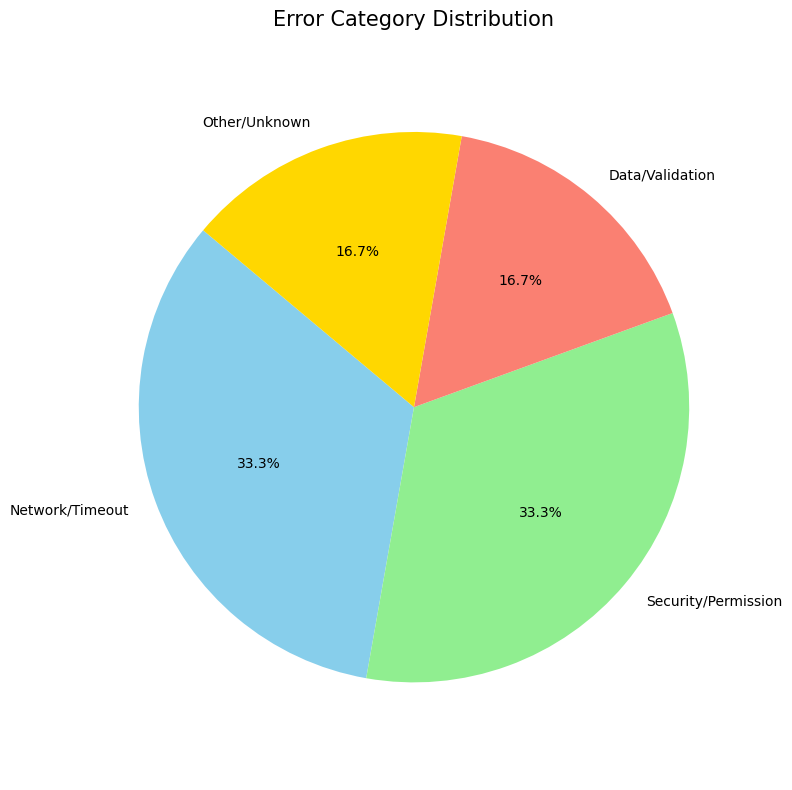

In [ ]:
import matplotlib.pyplot as plt

# 1. データの準備（集計結果を使用）
# summary は前回のコードで作成した df_logs['Category'].value_counts() です
labels = summary['Category']
counts = summary['Count']

# 2. 円グラフの作成
plt.figure(figsize=(8, 8))
# autopct='%1.1f%%' でパーセンテージを表示します
# startangle=140 で見やすい角度から開始します
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=['skyblue', 'lightgreen', 'salmon', 'gold'])

# 3. タイトルとレイアウトの設定
plt.title('Error Category Distribution', fontsize=15)
plt.axis('equal')  # 円を正円にします

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. ログインログデータ
login_logs = {
    '時刻': pd.to_datetime(['2024-04-15 10:00', '2024-04-15 10:01', '2024-04-15 10:02',
                          '2024-04-15 10:02', '2024-04-15 10:03', '2024-04-15 10:03']),
    'IPアドレス': ['192.168.1.1', '192.168.1.1', '10.0.0.5', '192.168.1.1', '192.168.1.1', '10.0.0.5'],
    '結果': ['Fail', 'Fail', 'Success', 'Fail', 'Fail', 'Success']
}
df_login = pd.DataFrame(login_logs)

# 2. 失敗（Fail）したログのみを抽出
failed_attempts = df_login[df_login['結果'] == 'Fail']

# 3. IPアドレスごとに失敗回数をカウント
attack_summary = failed_attempts.groupby('IPアドレス').size().reset_index(name='失敗回数')

# 4. 3回以上失敗しているIPを「攻撃の疑い」として抽出
suspicious_ips = attack_summary[attack_summary['失敗回数'] >= 3]

print("--- 不正ログイン試行レポート ---")
if len(suspicious_ips) > 0:
    print(f"🚨 警告: 攻撃の疑いがあるIPアドレスが {len(suspicious_ips)} 件見つかりました。")
    display(suspicious_ips)
else:
    print("✅ 不審なログイン試行はありません。")

--- 不正ログイン試行レポート ---
🚨 警告: 攻撃の疑いがあるIPアドレスが 1 件見つかりました。


,IPアドレス,失敗回数
0,192.168.1.1,4


In [ ]:
# 1. 処理時間ログ（秒単位）
perf_data = {
    '処理名': ['InvoicePost', 'PaymentRun', 'InvoicePost', 'ReportGen', 'InvoicePost', 'PaymentRun'],
    '所要時間_秒': [2.5, 120.0, 3.1, 45.0, 250.0, 115.0] # 3回目のInvoicePostが異常に長い
}
df_perf = pd.DataFrame(perf_data)

# 2. 処理名ごとの「平均」と「最大」の所要時間を算出
performance_summary = df_perf.groupby('処理名')['所要時間_秒'].agg(['mean', 'max', 'count']).reset_index()

# 3. 平均の2倍以上の時間がかかっている個別の異常値を特定
# ここでは「200秒以上」を閾値（しきいち）として警告します
threshold = 200
slow_queries = df_perf[df_perf['所要時間_秒'] > threshold]

print("\n--- パフォーマンス統計レポート ---")
display(performance_summary)

if len(slow_queries) > 0:
    print(f"🐢 遅延検知: {threshold}秒以上かかっている処理が {len(slow_queries)} 件あります。改善を検討してください。")
    display(slow_queries)


--- パフォーマンス統計レポート ---


,処理名,mean,max,count
0,InvoicePost,85.2,250.0,3
1,PaymentRun,117.5,120.0,2
2,ReportGen,45.0,45.0,1


🐢 遅延検知: 200秒以上かかっている処理が 1 件あります。改善を検討してください。


,処理名,所要時間_秒
4,InvoicePost,250.0


In [ ]:
import pandas as pd
import numpy as np

# 1. 処理実行ログ（バッチ処理の履歴を想定）
# Batch_Aは安定、Batch_Bは非常に不安定なデータ
performance_logs = {
    'バッチ名': ['Batch_A']*5 + ['Batch_B']*5,
    '所要時間_秒': [10, 11, 10, 12, 10,  # Batch_A: 安定
                 5, 150, 10, 200, 12]  # Batch_B: 不安定（スパイクが発生）
}
df_perf = pd.DataFrame(performance_logs)

# 2. 統計量の算出（平均、最大、標準偏差）
# std() が標準偏差を計算するメソッドです
stats = df_perf.groupby('バッチ名')['所要時間_秒'].agg(['mean', 'max', 'std']).reset_index()

# 3. 安定性の評価
# 標準偏差が平均の 50% を超えている場合を「不安定」と定義してみます
stats['安定性評価'] = stats.apply(
    lambda x: '⚠️ 不安定 (Unstable)' if x['std'] > (x['mean'] * 0.5) else '✅ 安定 (Stable)',
    axis=1
)

print("--- バッチ処理 安定性解析レポート ---")
display(stats)

# 4. 不安定なバッチの理由を表示
unstable_batches = stats[stats['安定性評価'].str.contains('不安定')]
if len(unstable_batches) > 0:
    print(f"\n📢 エスカレーションが必要な候補: {unstable_batches['バッチ名'].tolist()}")
    print("理由: 標準偏差(std)が高く、処理時間に極端なばらつきがあります。リソース競合の調査を推奨します。")

--- バッチ処理 安定性解析レポート ---


,バッチ名,mean,max,std,安定性評価
0,Batch_A,10.6,12,0.894427,✅ 安定 (Stable)
1,Batch_B,75.4,200,92.659592,⚠️ 不安定 (Unstable)



📢 エスカレーションが必要な候補: ['Batch_B']
理由: 標準偏差(std)が高く、処理時間に極端なばらつきがあります。リソース競合の調査を推奨します。


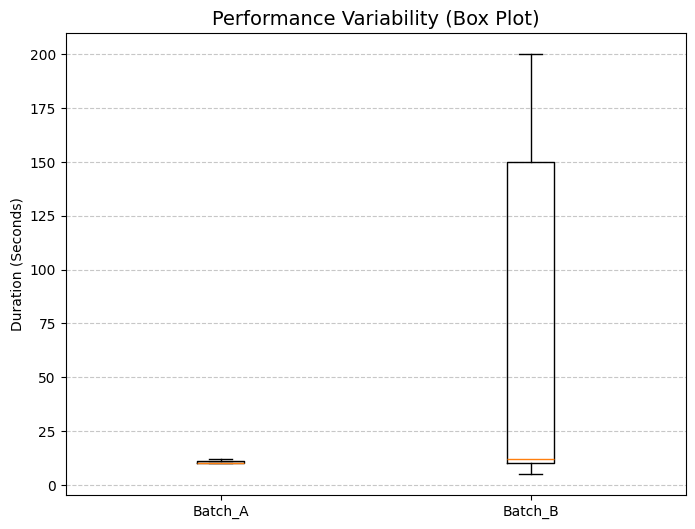

In [ ]:
import matplotlib.pyplot as plt

# 1. グラフの作成
plt.figure(figsize=(8, 6))

# boxplot関数に、バッチごとのデータを渡します
# バッチAのデータとバッチBのデータを分けてリスト化します
data_a = df_perf[df_perf['バッチ名'] == 'Batch_A']['所要時間_秒']
data_b = df_perf[df_perf['バッチ名'] == 'Batch_B']['所要時間_秒']

# plt.boxplot([data_a, data_b], labels=['Batch_A', 'Batch_B'])
plt.boxplot([data_a, data_b], tick_labels=['Batch_A', 'Batch_B'])

# 2. ラベルとタイトルの設定
plt.title('Performance Variability (Box Plot)', fontsize=14)
plt.ylabel('Duration (Seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
import pandas as pd
from google.colab import files

# 1. 調査したいカテゴリーを指定（例：Network/Timeout）
target_category = 'Network/Timeout'

# 2. 指定したカテゴリーのみを抽出
investigation_df = df_logs[df_logs['Category'] == target_category].copy()

# 3. 調査に不要な列があれば削除し、必要な情報を整える
# 今回はシンプルにそのまま出力します
output_data = investigation_df[['LogID', 'Message']]

# 4. CSVファイルとして書き出し
# ファイル名にカテゴリー名を含めると親切です
file_name = f"Investigation_Report_{target_category.replace('/', '_')}.csv"
output_data.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"--- 調査資料作成レポート ---")
print(f"✅ カテゴリー '{target_category}' のデータを {len(output_data)} 件抽出しました。")
print(f"✅ ファイル '{file_name}' を作成しました。")

# 5. ローカルPCへダウンロード
files.download(file_name)

--- 調査資料作成レポート ---
✅ カテゴリー 'Network/Timeout' のデータを 2 件抽出しました。
✅ ファイル 'Investigation_Report_Network_Timeout.csv' を作成しました。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# ※ 前回のセルで作成したクリーニング済みの `df_item` を使用します

# 1. 出力する列を整理（インポートに必要な列だけに絞るのが実務的です）
# ここでは品目コードと、クリーニング後の品目名のみを抽出します
df_for_import = df_item[['品目コード', 'クリーニング後品目名']].copy()

# 2. 列名をD365のエンティティ（ItemNameなど）に合わせてリネーム（任意）
df_for_import.columns = ['ItemNumber', 'ItemName']

# 3. CSVファイルとして書き出し
# utf-8-sig を使うのが日本語環境での「お作法」です
csv_file = 'D365_Item_Import_Ready.csv'
df_for_import.to_csv(csv_file, index=False, encoding='utf-8-sig', quoting=1)

print(f"✅ インポート用ファイル '{csv_file}' を作成しました。")

# 4. ローカルPCへダウンロード
files.download(csv_file)

✅ インポート用ファイル 'D365_Item_Import_Ready.csv' を作成しました。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# 1. 項目が欠落しているマスタデータ（模擬データ）
# ※ 200は科目名が欠落、300はBSなのに税区分が欠落している想定
master_data = {
    '勘定科目コード': [100, 200, 300, 400],
    '科目名': ['現金', np.nan, '売掛金', '売上高'],
    '勘定タイプ': ['BS', 'BS', 'BS', 'PL'],
    '税区分': ['非課税', '非課税', np.nan, '課税']
}
df_master = pd.DataFrame(master_data)

# 2. 全般的な欠損値（空欄）のチェック
# isnull() を使うことで、どこに空欄があるか一瞬でわかります
missing_any = df_master[df_master.isnull().any(axis=1)]

# 3. 業務ルールに基づいた特定の不整合チェック
# ルール: 「勘定タイプが BS」かつ「税区分が空(null)」のものを探す
rule_violation = df_master[
    (df_master['勘定タイプ'] == 'BS') & (df_master['税区分'].isnull())
]

print("--- マスタ項目バリデーションレポート ---")

# レポート出力1: 単純な空欄チェック
if len(missing_any) > 0:
    print(f"⚠️ 全般警告: 項目が未入力の行が {len(missing_any)} 件あります。")
    display(missing_any)

# レポート出力2: 業務ルール違反チェック
if len(rule_violation) > 0:
    print(f"\n🚫 業務ルール違反: BS科目で税区分が未設定の重大なエラーが {len(rule_violation)} 件あります。")
    display(rule_violation[['勘定科目コード', '科目名', '勘定タイプ']])
else:
    print("\n✅ すべてのBS科目に税区分が設定されています。")

--- マスタ項目バリデーションレポート ---
⚠️ 全般警告: 項目が未入力の行が 2 件あります。


,勘定科目コード,科目名,勘定タイプ,税区分
1,200,NaN,BS,非課税
2,300,売掛金,BS,NaN



🚫 業務ルール違反: BS科目で税区分が未設定の重大なエラーが 1 件あります。


,勘定科目コード,科目名,勘定タイプ
2,300,売掛金,BS


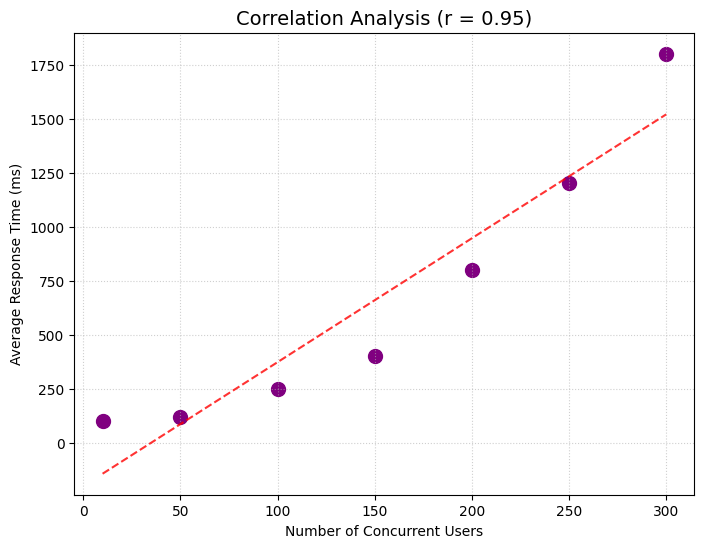

--- 分析結果 ---
📈 相関係数: 0.95
🚩 強い相関を検知：同時接続数の増加がレスポンス低下の直接的な原因である可能性が高いです。


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. サーバーの負荷ログ（模擬データ）
# 負荷（同時接続数）が増えるほど、処理時間が伸びているようなデータを想定
load_data = {
    '時刻': ['10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00'],
    '同時接続数': [10, 50, 100, 150, 200, 250, 300],
    '平均応答時間_ms': [100, 120, 250, 400, 800, 1200, 1800] # 急激に伸びている
}
df_load = pd.DataFrame(load_data)

# 2. 相関係数（Correlation）の算出
# 1に近いほど「強い正の相関」があり、一方が増えるともう一方も増えることを意味します
correlation = df_load['同時接続数'].corr(df_load['平均応答時間_ms'])

# 3. 散布図（Scatter Plot）による可視化
plt.figure(figsize=(8, 6))
plt.scatter(df_load['同時接続数'], df_load['平均応答時間_ms'], color='purple', s=100)

# 近似線（トレンドライン）の追加
import numpy as np
z = np.polyfit(df_load['同時接続数'], df_load['平均応答時間_ms'], 1)
p = np.poly1d(z)
plt.plot(df_load['同時接続数'], p(df_load['同時接続数']), "r--", alpha=0.8)

plt.title(f'Correlation Analysis (r = {correlation:.2f})', fontsize=14)
plt.xlabel('Number of Concurrent Users')
plt.ylabel('Average Response Time (ms)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

print(f"--- 分析結果 ---")
print(f"📈 相関係数: {correlation:.2f}")
if correlation > 0.8:
    print("🚩 強い相関を検知：同時接続数の増加がレスポンス低下の直接的な原因である可能性が高いです。")

--- 未来予測レポート ---
📈 予測モデル: 応答時間 = 5.74 × 接続数 + -201.51
🔮 予測結果: 同時接続数が 500 名に達した時、
   平均応答時間は 【2666.7 ms】 まで悪化すると予測されます。


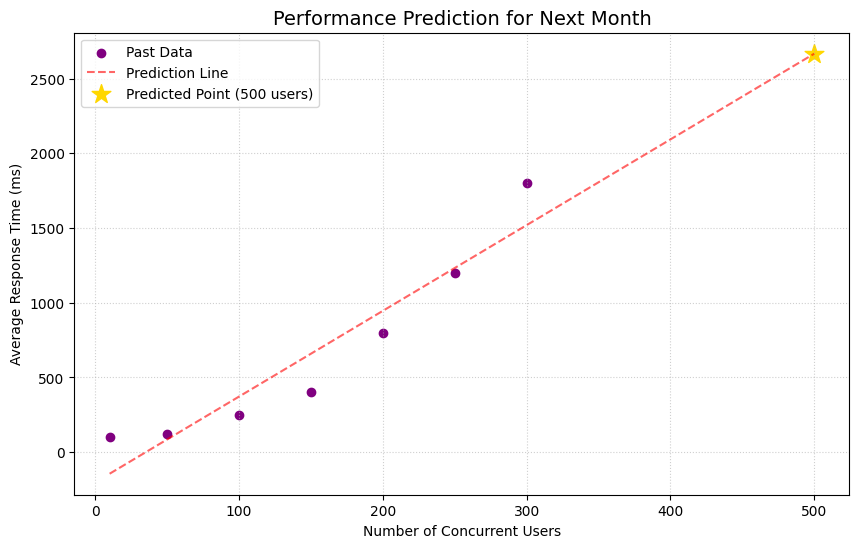

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 過去データの準備（前回のデータを使用）
x_past = df_load['同時接続数']
y_past = df_load['平均応答時間_ms']

# 2. 線形回帰モデルの作成 (y = ax + b)
# np.polyfit で傾き(a)と切片(b)を算出します
a, b = np.polyfit(x_past, y_past, 1)

# 3. 来月の予測（同時接続数 500 の時）
future_users = 500
predicted_response_time = a * future_users + b

print(f"--- 未来予測レポート ---")
print(f"📈 予測モデル: 応答時間 = {a:.2f} × 接続数 + {b:.2f}")
print(f"🔮 予測結果: 同時接続数が {future_users} 名に達した時、")
print(f"   平均応答時間は 【{predicted_response_time:.1f} ms】 まで悪化すると予測されます。")

# 4. 可視化
plt.figure(figsize=(10, 6))
# 過去データの散布図
plt.scatter(x_past, y_past, color='purple', label='Past Data')
# 回帰線（トレンドライン）
x_range = np.array([min(x_past), future_users])
plt.plot(x_range, a * x_range + b, 'r--', alpha=0.6, label='Prediction Line')
# 予測ポイント
plt.scatter(future_users, predicted_response_time, color='gold', s=200, marker='*', label='Predicted Point (500 users)')

plt.title('Performance Prediction for Next Month', fontsize=14)
plt.xlabel('Number of Concurrent Users')
plt.ylabel('Average Response Time (ms)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
import datetime

# 1. SLAの設定（2秒 = 2000ms を超えたら警告）
SLA_THRESHOLD = 2000
target_date = (datetime.datetime.now() + datetime.timedelta(days=30)).strftime('%Y-%m-%d')

# 2. 自動判定とメッセージ生成
def generate_alert_email(predicted_value, threshold, user_count):
    if predicted_value > threshold:
        # 警告文のテンプレート（f-stringを使用）
        subject = f"【Alert】System Performance Prediction Risk - {target_date}"
        body = f"""
Dear System Administration Team,

This is an automated performance risk alert based on our latest regression analysis.

[Summary]
Our predictive model indicates that the system response time will exceed the agreed SLA threshold ({threshold} ms) within the next 30 days.

[Prediction Details]
- Estimated Date: {target_date}
- Predicted User Load: {user_count} concurrent users
- Predicted Response Time: {predicted_value:.1f} ms (SLA Violation: +{predicted_value - threshold:.1f} ms)

[Recommendation]
Immediate investigation into server resource scaling (CPU/Memory) or database query optimization is required to prevent a potential service outage.

This report was automatically generated by the Performance Forecasting Tool.
--------------------------------------------------
GitHub Repo: [Your GitHub URL]
        """
        return subject, body
    else:
        return None, "System performance is within expected SLA parameters."

# 3. 実行
subject, email_content = generate_alert_email(predicted_response_time, SLA_THRESHOLD, future_users)

print("--- 自動生成された警告メール本文 ---")
if subject:
    print(f"Subject: {subject}")
    print(email_content)
else:
    print(email_content)

--- 自動生成された警告メール本文 ---
Subject: 【Alert】System Performance Prediction Risk - 2026-05-20

Dear System Administration Team,

This is an automated performance risk alert based on our latest regression analysis.

[Summary]
Our predictive model indicates that the system response time will exceed the agreed SLA threshold (2000 ms) within the next 30 days.

[Prediction Details]
- Estimated Date: 2026-05-20
- Predicted User Load: 500 concurrent users
- Predicted Response Time: 2666.7 ms (SLA Violation: +666.7 ms)

[Recommendation]
Immediate investigation into server resource scaling (CPU/Memory) or database query optimization is required to prevent a potential service outage.

This report was automatically generated by the Performance Forecasting Tool.
--------------------------------------------------
GitHub Repo: [Your GitHub URL]
        


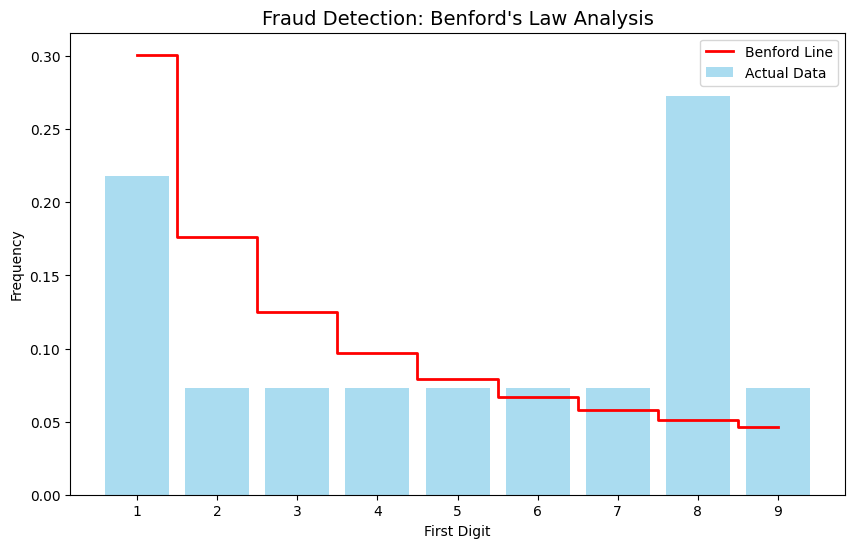

🚩 異常検知: 数字 '8' で始まる金額が 27.3% も存在します。
   これは自然な分布を逸脱しており、意図的な操作や特定のパターンのエラーが疑われます。


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 大量の仕訳金額データ（模擬データ）
# 意図的に「8」で始まる数字を多く混ぜて、不自然なデータを作ります
amounts = [120, 1500, 180, 250, 310, 4500, 560, 670, 780, 900] * 20
suspicious_data = [8800, 8120, 8500, 8000, 8990] * 15 # 「8」で始まる不自然なデータ
df_audit = pd.DataFrame({'Amount': amounts + suspicious_data})

# 2. 先頭の数字（First Digit）を抽出
df_audit['First_Digit'] = df_audit['Amount'].astype(str).str[0].astype(int)

# 3. 実際の出現頻度を計算
actual_counts = df_audit['First_Digit'].value_counts(normalize=True).sort_index()

# 4. ベンフォードの法則の理論値（理想的な分布）
benford_theoretical = [0.301, 0.176, 0.125, 0.097, 0.079, 0.067, 0.058, 0.051, 0.046]

# 5. 可視化して比較
plt.figure(figsize=(10, 6))
plt.bar(range(1, 10), actual_counts, alpha=0.7, label='Actual Data', color='skyblue')
plt.step(range(1, 10), benford_theoretical, where='mid', color='red', label='Benford Line', linewidth=2)

plt.title("Fraud Detection: Benford's Law Analysis", fontsize=14)
plt.xlabel('First Digit')
plt.ylabel('Frequency')
plt.xticks(range(1, 10))
plt.legend()
plt.show()

# 6. 異常の特定
if actual_counts[8] > 0.1: # 8の出現率が異常に高い場合
    print(f"🚩 異常検知: 数字 '8' で始まる金額が {actual_counts[8]*100:.1f}% も存在します。")
    print("   これは自然な分布を逸脱しており、意図的な操作や特定のパターンのエラーが疑われます。")

In [ ]:
import pandas as pd

# 1. 形式が不適切なマスタデータ（模擬データ）
# ※ 5001 (5桁でNG), 600A (文字混入でNG), 0700 (0開始でNG)
master_raw = {
    '勘定科目コード': ['1000', '2000', '50001', '600A', '0700'],
    '科目名': ['現金', '普通預金', '固定資産', '支払利息', '雑費']
}
df_master = pd.DataFrame(master_raw)

# 2. 形式チェックロジック
# 2-1. 桁数チェック (4桁以外を抽出)
df_master['桁数'] = df_master['勘定科目コード'].str.len()
invalid_length = df_master[df_master['桁数'] != 4]

# 2-2. 数字のみチェック (数字以外が含まれるものを抽出)
# isdigit() を使って判定
invalid_type = df_master[~df_master['勘定科目コード'].str.isdigit()]

# 2-3. 先頭文字チェック (0から始まるものを抽出)
invalid_start = df_master[df_master['勘定科目コード'].str.startswith('0')]

# 3. レポート出力
print("--- データ形式バリデーションレポート ---")

if len(invalid_length) > 0:
    print(f"⚠️ 桁数エラー: 4桁ではないコードが {len(invalid_length)} 件あります。")
    display(invalid_length)

if len(invalid_type) > 0:
    print(f"🚫 型エラー: 数字以外の文字が含まれるコードが {len(invalid_type)} 件あります。")
    display(invalid_type)

if len(invalid_start) > 0:
    print(f"🛑 運用ルール違反: '0'から始まる無効なコードが {len(invalid_start)} 件あります。")
    display(invalid_start)

--- データ形式バリデーションレポート ---
⚠️ 桁数エラー: 4桁ではないコードが 1 件あります。


,勘定科目コード,科目名,桁数
2,50001,固定資産,5


🚫 型エラー: 数字以外の文字が含まれるコードが 1 件あります。


,勘定科目コード,科目名,桁数
3,600A,支払利息,4


🛑 運用ルール違反: '0'から始まる無効なコードが 1 件あります。


,勘定科目コード,科目名,桁数
4,0700,雑費,4


In [ ]:
import pandas as pd
import unicodedata

# 1. データの準備
df_old = pd.DataFrame({
    '旧コード': ['100', '200', '300'],
    '名称': ['現金　', '普通預金', '売掛金']
})

df_new = pd.DataFrame({
    '新コード': ['1000', '2000', '3000'],
    '名称': ['現金', '普通預金', 'ｳﾘｶｹｷﾝ'] # 半角カナ
})

# 2. 【重要】辞書のキーを正規化（NFKC）後の「全角カナ」で定義する
# NFKCを通ると半角の 'ｳﾘｶｹｷﾝ' は 全角の 'ウリカケキン' になります
name_mapping = {
    'ウリカケキン': '売掛金',
    'ゲンキン': '現金'
}

# 3. クレンジング関数
def advanced_normalize(text):
    if not isinstance(text, str):
        return text

    # a. ここで「全角」に統一される（半角カナ -> 全角カナ）
    clean_text = unicodedata.normalize('NFKC', text).strip()

    # b. 統一された状態（全角カナ）で辞書を引く
    return name_mapping.get(clean_text, clean_text)

# 4. 適用
df_old['名称_final'] = df_old['名称'].apply(advanced_normalize)
df_new['名称_final'] = df_new['名称'].apply(advanced_normalize)

# 5. 突合
df_matched = pd.merge(df_old, df_new, on='名称_final', how='inner')

print("--- 高度な名寄せ（NFKC考慮版）レポート ---")
display(df_matched[['名称_final', '旧コード', '新コード']])

--- 高度な名寄せ（NFKC考慮版）レポート ---


,名称_final,旧コード,新コード
0,現金,100,1000
1,普通預金,200,2000
2,売掛金,300,3000


In [ ]:
import pandas as pd

# 1. 形式がバラバラな日付データ
date_data = {
    '伝票番号': ['V1', 'V2', 'V3', 'V4'],
    '取引日': ['2024/04/15', '2024.04.16', '20240417', 'invalid-date']
}
df_date = pd.DataFrame(date_data)

# 2. pd.to_datetime を使って一括変換
# errors='coerce' を使うことで、解析不能な文字列を NaT (Not a Time) に変換し、エラー停止を防ぎます
df_date['正規化日付'] = pd.to_datetime(df_date['取引日'], errors='coerce')

# 3. D365形式 (YYYY-MM-DD) の文字列に変換
df_date['D365形式'] = df_date['正規化日付'].dt.strftime('%Y-%m-%d')

print("--- 日付正規化レポート ---")
display(df_date)

# NaT (変換失敗) がある場合の警告
errors = df_date[df_date['正規化日付'].isnull()]
if len(errors) > 0:
    print(f"⚠️ 警告: 日付として認識できないデータが {len(errors)} 件あります。")

--- 日付正規化レポート ---


,伝票番号,取引日,正規化日付,D365形式
0,V1,2024/04/15,2024-04-15,2024-04-15
1,V2,2024.04.16,NaT,NaN
2,V3,20240417,NaT,NaN
3,V4,invalid-date,NaT,NaN


⚠️ 警告: 日付として認識できないデータが 3 件あります。


In [ ]:
import pandas as pd
import numpy as np

# 1. 様々なエラーを含んだテストデータ
master_raw = {
    '勘定科目コード': ['1000', '2000', '50001', '600A', '0700', '1000'], # 1000が重複
    '科目名': ['現金', '普通預金', '固定資産', np.nan, '雑費', '現金']
}
df = pd.DataFrame(master_raw)

# 2. 統合バリデーションの実行
# 2-1. 桁数エラー (4桁以外)
df['Err_桁数'] = df['勘定科目コード'].str.len() != 4

# 2-2. 型エラー (数字以外)
df['Err_型'] = ~df['勘定科目コード'].str.isdigit()

# 2-3. 空欄エラー (科目名がNaN)
df['Err_空欄'] = df['科目名'].isnull()

# 2-4. 重複エラー (コードが重複)
df['Err_重複'] = df.duplicated(subset=['勘定科目コード'], keep=False)

# 3. エラーの集計
# True(1) と False(0) を足して、その行にいくつエラーがあるか算出
error_columns = ['Err_桁数', 'Err_型', 'Err_空欄', 'Err_重複']
df['エラー件数'] = df[error_columns].sum(axis=1)

# 4. エラーがある行だけを抽出した「統合レポート」
error_report = df[df['エラー件数'] > 0].copy()

print("--- 統合データバリデーション・レポート ---")
if len(error_report) > 0:
    print(f"⚠️ 修正が必要な行が {len(error_report)} 件あります。")
    # 見やすくするために、エラーがない列は非表示にしたり並べ替えたりします
    display(error_report)
else:
    print("✅ 完璧です！すべてのデータが正常です。")

--- 統合データバリデーション・レポート ---
⚠️ 修正が必要な行が 4 件あります。


,勘定科目コード,科目名,Err_桁数,Err_型,Err_空欄,Err_重複,エラー件数
0,1000,現金,False,False,False,True,1
2,50001,固定資産,True,False,False,False,1
3,600A,NaN,False,True,True,False,2
5,1000,現金,False,False,False,True,1


In [ ]:
import pandas as pd

# ※ 前回のセルで作成した `error_report` が存在することが前提です

# 1. Excelファイルとして書き出し
# ファイル名を 'Validation_Report.xlsx' とします
file_name = 'Master_Data_Validation_Report.xlsx'
error_report.to_excel(file_name, index=False)

print(f"✅ Excelファイル '{file_name}' を作成しました。")

# 2. Google ColabからローカルPCへダウンロードするためのコード
from google.colab import files
files.download(file_name)

✅ Excelファイル 'Master_Data_Validation_Report.xlsx' を作成しました。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

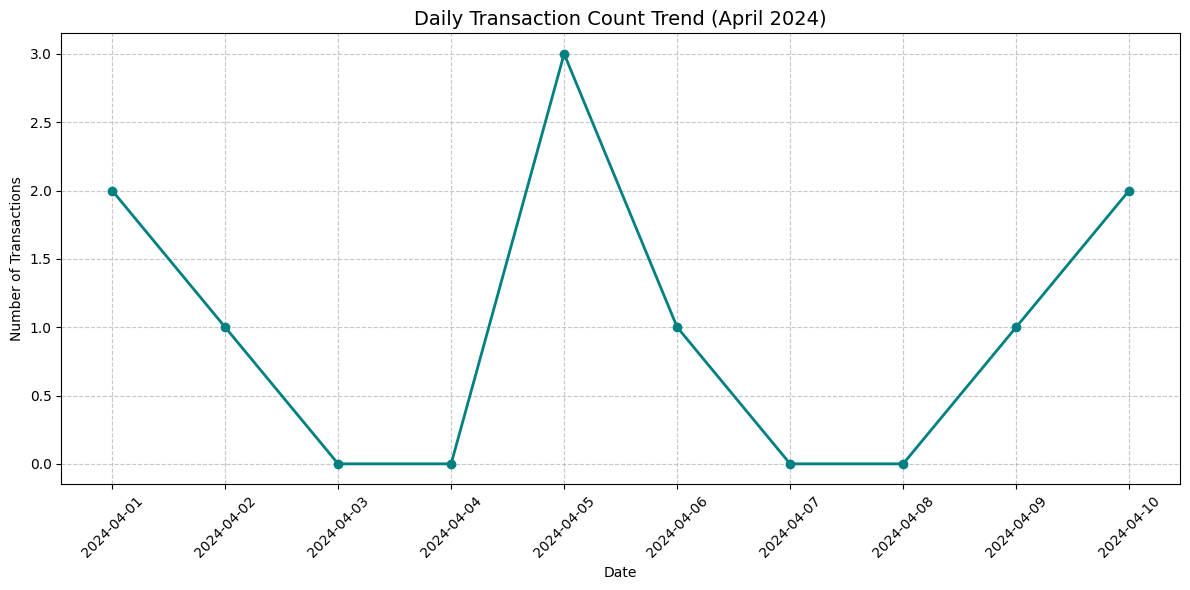

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. サンプルログデータ（4月初旬の10日間を想定）
trend_data = {
    '作成日時': [
        '2024-04-01 10:00:00', '2024-04-01 15:00:00',
        '2024-04-02 11:00:00',
        '2024-04-05 10:00:00', '2024-04-05 12:00:00', '2024-04-05 14:00:00', # 4/5に山
        '2024-04-06 09:00:00',
        '2024-04-09 13:00:00', '2024-04-10 10:00:00', '2024-04-10 16:00:00'
    ],
    '伝票番号': ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']
}
df_trend = pd.DataFrame(trend_data)
df_trend['作成日時'] = pd.to_datetime(df_trend['作成日時'])

# 2. 日次での集計 (D = Daily)
# set_index してから resample することで「日次」の件数を算出
daily_counts = df_trend.set_index('作成日時').resample('D').count()

# 3. 折れ線グラフの作成
plt.figure(figsize=(12, 6))
plt.plot(daily_counts.index, daily_counts['伝票番号'], marker='o', linestyle='-', color='teal', linewidth=2)

# 4. タイトルとラベル（英語）
plt.title('Daily Transaction Count Trend (April 2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True, linestyle='--', alpha=0.7) # グリッド線を追加して見やすく

# 日付の表示形式を調整
plt.xticks(daily_counts.index, [d.strftime('%Y-%m-%d') for d in daily_counts.index], rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. 勘定科目マスタ（正規のリスト）
# 本来は 100, 200, 300 しか存在しない
master_data = {
    '勘定科目コード': [100, 200, 300],
    '科目名': ['現金', '普通預金', '売掛金']
}
df_master = pd.DataFrame(master_data)

# 2. 実際に発生した仕訳データ
# ※ 伝票 V003 はマスタに存在しない「999」という不正なコードを使っている想定
journal_data = {
    '伝票番号': ['V001', 'V002', 'V003', 'V004'],
    '勘定科目コード': [100, 200, 999, 100],
    '金額': [5000, 8000, 15000, 3000]
}
df_journal = pd.DataFrame(journal_data)

# 3. 外部結合でマスタをぶつける
# how='left' を使うことで仕訳をすべて残しつつ、マスタ情報をくっつける
df_check = pd.merge(df_journal, df_master, on='勘定科目コード', how='left')

# 4. マスタに存在しない（科目名が NaN になっている）行を抽出
# これをエスカレーションエンジニアは「Orphaned Record (親なしレコード)」と呼びます
orphans = df_check[df_check['科目名'].isnull()]

print("--- マスタ整合性チェックレポート ---")
if len(orphans) > 0:
    print(f"⚠️ 致命的なエラー: マスタに未登録の勘定科目を使用している仕訳が {len(orphans)} 件あります。")
    display(orphans[['伝票番号', '勘定科目コード', '金額']])
else:
    print("✅ すべての仕訳は有効なマスタを参照しています。")

--- マスタ整合性チェックレポート ---
⚠️ 致命的なエラー: マスタに未登録の勘定科目を使用している仕訳が 1 件あります。


,伝票番号,勘定科目コード,金額
2,V003,999,15000


In [ ]:
import pandas as pd

# 1. 矛盾を含んだマスタデータ（模擬データ）
# ※ コード 100 に「現金」と「現預金」が混在している
master_data_raw = {
    '勘定科目コード': [100, 100, 200, 300, 300],
    '科目名': ['現金', '現預金', '普通預金', '売掛金', '売掛金'] # 300は重複だが名前は同じ
}
df_master = pd.DataFrame(master_data_raw)

# 2. まず「コードと名前」のユニークな組み合わせを作る
df_unique = df_master.drop_duplicates()

# 3. コードごとに「名前がいくつ登録されているか」をカウント
# nunique() はユニークな値の個数を数える関数です
name_counts = df_unique.groupby('勘定科目コード')['科目名'].nunique().reset_index()
name_counts.columns = ['勘定科目コード', '名前の種類数']

# 4. 種類数が 2 以上のものが「矛盾（不整合）」
inconsistent_codes = name_counts[name_counts['名前の種類数'] > 1]

# 5. 該当するコードの具体的な中身を表示
inconsistent_master = df_unique[df_unique['勘定科目コード'].isin(inconsistent_codes['勘定科目コード'])]

print("--- マスタ名称不整合（表記ゆれ）チェックレポート ---")
if len(inconsistent_master) > 0:
    print(f"⚠️ 警告: 同じコードに複数の名称が割り当てられている不整合が {len(inconsistent_codes)} 件あります。")
    display(inconsistent_master.sort_values('勘定科目コード'))
else:
    print("✅ マスタ内の名称はすべて統一されています。")

--- マスタ名称不整合（表記ゆれ）チェックレポート ---
⚠️ 警告: 同じコードに複数の名称が割り当てられている不整合が 1 件あります。


,勘定科目コード,科目名
0,100,現金
1,100,現預金


--- 短時間大量操作（バースト）検知レポート ---
⚠️ 警告: 短時間に大量の操作を行ったユーザーが 1 名見つかりました。


,作成者,作成日時,1分間内の件数
6,UserC,2024-04-10 17:05:40,5.0


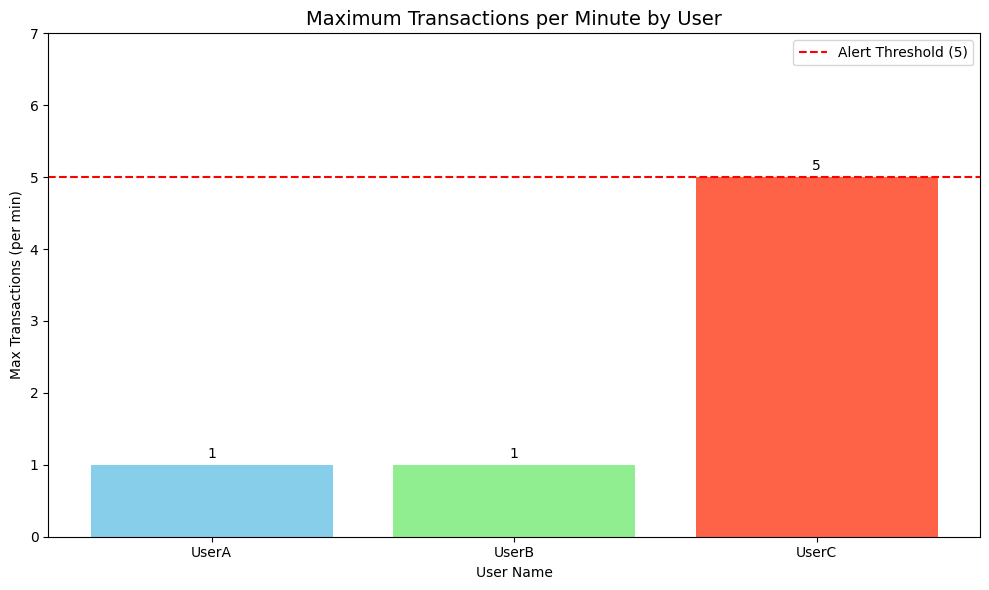

In [ ]:
import pandas as pd

# 1. 作成ログデータ
# UserC が短時間（17:05台）に連続して作成している想定
log_data = {
    '伝票番号': ['V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207'],
    '作成日時': [
        '2024-04-10 17:00:00',
        '2024-04-10 17:01:00',
        '2024-04-10 17:05:00', # UserC バースト開始
        '2024-04-10 17:05:10', # UserC
        '2024-04-10 17:05:20', # UserC
        '2024-04-10 17:05:30', # UserC
        '2024-04-10 17:05:40'  # UserC
    ],
    '作成者': ['UserA', 'UserB', 'UserC', 'UserC', 'UserC', 'UserC', 'UserC']
}
df_logs = pd.DataFrame(log_data)
df_logs['作成日時'] = pd.to_datetime(df_logs['作成日時'])

# 2. ユーザーごとに1分間のウィンドウで件数をカウントする
# ※ '1min' という指定で1分間の幅を見ます
df_logs = df_logs.sort_values('作成日時') # 時間順に並べ替え
df_logs = df_logs.set_index('作成日時')    # 時間をインデックス（索引）にする

# ユーザーごとにグループ化し、1分間（Rolling 1min）の件数を算出
burst_check = df_logs.groupby('作成者')['伝票番号'].rolling('1min').count()
burst_check = burst_check.reset_index()
burst_check.columns = ['作成者', '作成日時', '1分間内の件数']

# 3. 異常判定（1分間に5件以上を異常とする）
alert_threshold = 5
alerts = burst_check[burst_check['1分間内の件数'] >= alert_threshold]

print("--- 短時間大量操作（バースト）検知レポート ---")
if len(alerts) > 0:
    print(f"⚠️ 警告: 短時間に大量の操作を行ったユーザーが {len(alerts['作成者'].unique())} 名見つかりました。")
    display(alerts)
else:
    print("✅ 全てのユーザーの操作頻度は正常範囲内です。")

import matplotlib.pyplot as plt

# 4. ユーザーごとの「最大同時操作数」を抽出
# 各作成者の中で、最も高かった「1分間内の件数」を取得します
user_max_burst = burst_check.groupby('作成者')['1分間内の件数'].max().reset_index()

# 5. データの準備（英語表記に変換してグローバル対応）
# 日本語が含まれる場合は英語にマップします
user_labels = user_max_burst['作成者']
max_values = user_max_burst['1分間内の件数']

# 6. グラフの作成
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(user_labels, max_values, color=['skyblue', 'lightgreen', 'tomato'])

# 7. タイトルとラベルの設定（英語）
ax.set_title('Maximum Transactions per Minute by User', fontsize=14)
ax.set_xlabel('User Name')
ax.set_ylabel('Max Transactions (per min)')
ax.set_ylim(0, max(max_values) + 2) # 上部に少し余白を作る

# 8. 数値ラベルを棒の上に表示
ax.bar_label(bars, padding=3, fmt='%.0f')

# 異常値（しきい値5）に水平線を引く（エスカレーションエンジニアらしい演出）
ax.axhline(y=5, color='red', linestyle='--', label='Alert Threshold (5)')
ax.legend()

plt.tight_layout()
plt.show()

--- 予算対実績 差異分析レポート ---


,部門,予算額,実績額,差異,消化率(%),ステータス
0,営業部,5000000,4800000,200000,96.0,✅ 正常
1,マーケティング部,3000000,3100000,-100000,103.3,✅ 正常
2,開発部,8000000,9500000,-1500000,118.8,⚠️ 超過(Over)
3,人事部,1500000,600000,900000,40.0,ℹ️ 未消化(Under)
4,総務部,1000000,1050000,-50000,105.0,✅ 正常



--- 要確認部門リスト ---


,部門,予算額,実績額,差異,消化率(%),ステータス
2,開発部,8000000,9500000,-1500000,118.8,⚠️ 超過(Over)
3,人事部,1500000,600000,900000,40.0,ℹ️ 未消化(Under)


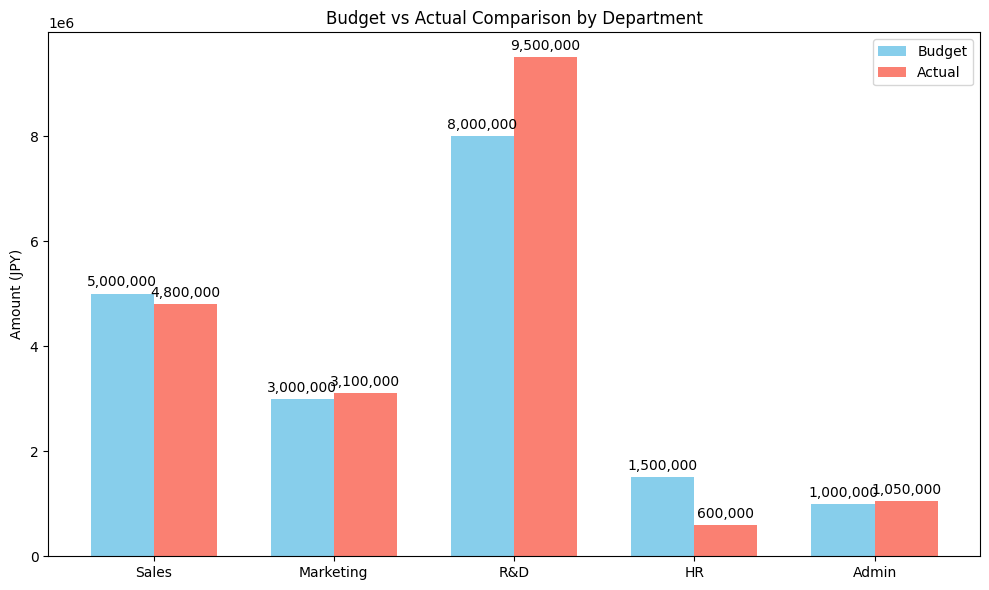

In [ ]:
import pandas as pd

# 1. 予算データ (Budget)
budget_data = {
    '部門': ['営業部', 'マーケティング部', '開発部', '人事部', '総務部'],
    '予算額': [5000000, 3000000, 8000000, 1500000, 1000000]
}
df_budget = pd.DataFrame(budget_data)

# 2. 実績データ (Actual)
# ※ 開発部が予算超過、人事部が極端に未消化の想定
actual_data = {
    '部門': ['営業部', 'マーケティング部', '開発部', '人事部', '総務部'],
    '実績額': [4800000, 3100000, 9500000, 600000, 1050000]
}
df_actual = pd.DataFrame(actual_data)

# 3. 予実比較の統合
df_vansa = pd.merge(df_budget, df_actual, on='部門')

# 4. 差異と消化率の計算
df_vansa['差異'] = df_vansa['予算額'] - df_vansa['実績額']
df_vansa['消化率(%)'] = (df_vansa['実績額'] / df_vansa['予算額'] * 100).round(1)

# 5. 異常値（Alert）の判定ロジック
# 消化率が110%以上、または50%以下を異常とする
def judge_alert(percent):
    if percent >= 110:
        return "⚠️ 超過(Over)"
    elif percent <= 50:
        return "ℹ️ 未消化(Under)"
    else:
        return "✅ 正常"

df_vansa['ステータス'] = df_vansa['消化率(%)'].apply(judge_alert)

print("--- 予算対実績 差異分析レポート ---")
display(df_vansa)

# 6. アラート対象のみ抽出
alerts = df_vansa[df_vansa['ステータス'] != "✅ 正常"]
print("\n--- 要確認部門リスト ---")
display(alerts)

import matplotlib.pyplot as plt
import numpy as np

# 日本語フォントの設定（Colabで日本語を表示するための簡易設定）
plt.rcParams['font.family'] = 'sans-serif'

# 7. データの準備（英語にマッピング）
# 日本語の部門名を英語に変換して表示用にする
dept_map = {
    '営業部': 'Sales',
    'マーケティング部': 'Marketing',
    '開発部': 'R&D',
    '人事部': 'HR',
    '総務部': 'Admin'
}
labels = df_vansa['部門'].map(dept_map)
budget = df_vansa['予算額']
actual = df_vansa['実績額']

x = np.arange(len(labels))
width = 0.35

# 8. グラフの作成
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, budget, width, label='Budget', color='skyblue')
rects2 = ax.bar(x + width/2, actual, width, label='Actual', color='salmon')

# 8. ラベルやタイトルの設定（英語）
ax.set_ylabel('Amount (JPY)')
ax.set_title('Budget vs Actual Comparison by Department')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# 9. 棒の上に数値を表示する（オプション）
ax.bar_label(rects1, padding=3, fmt='{:,.0f}')
ax.bar_label(rects2, padding=3, fmt='{:,.0f}')

fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. 大量の仕訳データ（模擬データ）
# ※ V003 と V005 が、日付・科目・金額がすべて同じ「重複」の疑いがあるデータ
journal_data = {
    '伝票番号': ['V001', 'V002', 'V003', 'V004', 'V005'],
    '取引日': ['2024-04-01', '2024-04-02', '2024-04-03', '2024-04-04', '2024-04-03'],
    '勘定科目': ['交際費', '消耗品費', '支払手数料', '通信費', '支払手数料'],
    '金額': [5000, 2000, 15000, 3000, 15000],
    '作成者': ['UserA', 'UserB', 'UserA', 'UserC', 'UserA']
}
df_journal = pd.DataFrame(journal_data)

# 2. 重複チェックロジック
# 「取引日」「勘定科目」「金額」の3つが一致するものを探す
# keep=False を指定すると、重複している行すべてを抽出できる
duplicates = df_journal[df_journal.duplicated(subset=['取引日', '勘定科目', '金額'], keep=False)]

print("--- 重複仕訳（二重計上）の疑いがあるデータ ---")
if len(duplicates) > 0:
    print(f"⚠️ 警告: 重複の可能性がある仕訳が {len(duplicates)} 件見つかりました。")
    display(duplicates.sort_values(by=['取引日', '金額']))
else:
    print("✅ 重複した仕訳は見つかりませんでした。")

# 3. (応用) 重複の「理由」を推測するヒント
# 同じ作成者が短時間に操作した可能性などを分析

--- 重複仕訳（二重計上）の疑いがあるデータ ---
⚠️ 警告: 重複の可能性がある仕訳が 2 件見つかりました。


,伝票番号,取引日,勘定科目,金額,作成者
2,V003,2024-04-03,支払手数料,15000,UserA
4,V005,2024-04-03,支払手数料,15000,UserA


In [ ]:
import pandas as pd

# 1. 作成日時を含む仕訳データ
audit_data = {
    '伝票番号': ['V101', 'V102', 'V103', 'V104', 'V105'],
    '作成日時': [
        '2024-04-01 10:00:00', # 月曜 10時 (正常)
        '2024-04-06 14:00:00', # 土曜 14時 (休日)
        '2024-04-03 23:30:00', # 水曜 23時半 (深夜)
        '2024-04-04 09:15:00', # 木曜 09時 (正常)
        '2024-04-07 02:00:00'  # 日曜 02時 (休日かつ深夜)
    ],
    '金額': [50000, 120000, 3000, 45000, 800000],
    '作成者': ['UserA', 'UserB', 'UserC', 'UserA', 'UserB']
}
df_audit = pd.DataFrame(audit_data)

# 2. 文字列を日付型（datetime）に変換
df_audit['作成日時'] = pd.to_datetime(df_audit['作成日時'])

# 3. 曜日（0=月, 6=日）と時間（0-23）を抽出
df_audit['曜日'] = df_audit['作成日時'].dt.weekday
df_audit['時間'] = df_audit['作成日時'].dt.hour

# 4. 異常判定ロジック
# 条件1: 曜日が土日 (5 または 6)
# 条件2: 時間が 22時以降 または 5時未満
is_weekend = df_audit['曜日'] >= 5
is_late_night = (df_audit['時間'] >= 22) | (df_audit['時間'] < 5)

# いずれかの条件に当てはまるものを抽出
suspicious_logs = df_audit[is_weekend | is_late_night].copy()

# 表示用に曜日の名前を追加
weekday_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
suspicious_logs['曜日名'] = suspicious_logs['曜日'].map(weekday_names)

print("--- 不自然な時間帯・曜日の仕訳ログ ---")
if len(suspicious_logs) > 0:
    print(f"⚠️ 警告: 内部統制上の確認が必要な仕訳が {len(suspicious_logs)} 件あります。")
    display(suspicious_logs[['伝票番号', '作成日時', '曜日名', '時間', '作成者', '金額']])
else:
    print("✅ すべての仕訳は標準的な営業時間内に作成されています。")

--- 不自然な時間帯・曜日の仕訳ログ ---
⚠️ 警告: 内部統制上の確認が必要な仕訳が 3 件あります。


,伝票番号,作成日時,曜日名,時間,作成者,金額
1,V102,2024-04-06 14:00:00,Sat,14,UserB,120000
2,V103,2024-04-03 23:30:00,Wed,23,UserC,3000
4,V105,2024-04-07 02:00:00,Sun,2,UserB,800000


In [ ]:
import pandas as pd

# 1. 各法人の個別試算表（TB）データ
# 1. 親会社のデータ
parent_data = {
    '勘定科目': ['売上高', '売上高', '売上原価', '一般管理費'],
    '金額': [-4000000, -1000000, 3000000, 1000000], # 子会社分を-100万にする
    '相手先': ['外部企業', '子会社A', '外部企業', '外部企業']
}
df_parent = pd.DataFrame(parent_data)

# 子会社A
sub_data = {
    '勘定科目': ['売上高', '売上原価', '一般管理費', '買掛金'],
    '金額': [-2000000, 1000000, 500000, -1500000],
    '相手先': ['外部企業', '親会社', '外部企業', '親会社']
}

df_parent = pd.DataFrame(parent_data)
df_sub = pd.DataFrame(sub_data)

# 2. 単純合算（連結の第一歩）
df_combined = pd.concat([df_parent, df_sub]).groupby('勘定科目')['金額'].sum().reset_index()
df_combined.rename(columns={'金額': '合算金額'}, inplace=True)

# 3. 内部取引消去ロジック
# 親会社の「売上（対子会社）」と子会社の「売上原価（対親会社）」を特定して消去
# elimination_amount = 1000000 # 相殺額
# ① データを手入力せず、親会社の「対子会社売上」から自動計算する
intercompany_sales = df_parent[
    (df_parent['勘定科目'] == '売上高') & (df_parent['相手先'] == '子会社A')
]['金額'].sum()

# 売上はマイナス表記なので、絶対値（abs）にして消去額とする
elimination_amount = abs(intercompany_sales)

print(f"自動抽出された相殺額: {elimination_amount:,}円")

# 消去仕訳のデータフレーム作成
elim_data = [
    {'勘定科目': '売上高', '消去額': elimination_amount},     # 売上のマイナス（貸方）を消すためにプラス
    {'勘定科目': '売上原価', '消去額': -elimination_amount} # 原価のプラス（借方）を消すためにマイナス
]
df_elim = pd.DataFrame(elim_data)

# 4. 最終連結財務諸表の作成
df_final = pd.merge(df_combined, df_elim, on='勘定科目', how='left').fillna(0)
df_final['連結金額'] = df_final['合算金額'] + df_final['消去額']

print("--- 連結決算ワークシート ---")
display(df_final[['勘定科目', '合算金額', '消去額', '連結金額']])

自動抽出された相殺額: 1,000,000円
--- 連結決算ワークシート ---


,勘定科目,合算金額,消去額,連結金額
0,一般管理費,1500000,0.0,1500000.0
1,売上原価,4000000,-1000000.0,3000000.0
2,売上高,-7000000,1000000.0,-6000000.0
3,買掛金,-1500000,0.0,-1500000.0


In [ ]:
import pandas as pd

# 1. 取引データ（請求時と支払時のデータ）
# ※ 伝票 FX003 は、入力された損益額が間違っている想定（計算チェック用）
exchange_data = {
    '取引ID': ['FX001', 'FX002', 'FX003'],
    '外貨額_USD': [100.0, 250.0, 150.0],
    '請求時レート': [150.0, 151.0, 149.0],
    '支払時レート': [155.0, 148.0, 152.0],
    '入力済為替損益': [-500, 750, -100] # FX003は本来 -450のはず
}
df_fx = pd.DataFrame(exchange_data)

# 2. 為替差損益の計算ロジック
# 計算式: 外貨額 * (請求時レート - 支払時レート)
# ※ 正数なら「益」、負数なら「損」
df_fx['理論上の為替損益'] = (
    df_fx['外貨額_USD'] * (df_fx['請求時レート'] - df_fx['支払時レート'])
).astype(int)

# 3. 誤差の検知
df_fx['計算誤差'] = df_fx['入力済為替損益'] - df_fx['理論上の為替損益']
error_fx = df_fx[df_fx['計算誤差'] != 0]

print("--- 為替差損益（実現損益）検証レポート ---")
if len(error_fx) > 0:
    print(f"⚠️ 警告: 為替差損益の計算不整合が {len(error_fx)} 件あります。")
    display(error_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '入力済為替損益', '計算誤差']])
else:
    print("✅ すべての為替差損益が正しく計上されています。")

--- 為替差損益（実現損益）検証レポート ---
⚠️ 警告: 為替差損益の計算不整合が 1 件あります。


,取引ID,外貨額_USD,理論上の為替損益,入力済為替損益,計算誤差
2,FX003,150.0,-450,-100,350


In [ ]:
import pandas as pd

# 1. 判定用の関数を定義
def judge_gain_loss(amount):
    if amount > 0:
        return "為替差益"
    elif amount < 0:
        return "為替差損"
    else:
        return "差損益なし"

# 2. 取引データ（請求時と支払時のデータ）
# ※ 伝票 FX003 は、入力された損益額が間違っている想定（計算チェック用）
exchange_data = {
    '取引ID': ['FX001', 'FX002', 'FX003'],
    '外貨額_USD': [100.0, 250.0, 150.0],
    '請求時レート': [150.0, 151.0, 149.0],
    '支払時レート': [155.0, 148.0, 152.0],
    '入力済為替損益': [-500, 750, -100] # FX003は本来 -450のはず
}
df_fx = pd.DataFrame(exchange_data)

# 2. 為替差損益の計算ロジック
# 計算式: 外貨額 * (請求時レート - 支払時レート)
# ※ 正数なら「益」、負数なら「損」
df_fx['理論上の為替損益'] = (
    df_fx['外貨額_USD'] * (df_fx['請求時レート'] - df_fx['支払時レート'])
).astype(int)

# 3. 誤差の検知
df_fx['計算誤差'] = df_fx['入力済為替損益'] - df_fx['理論上の為替損益']
error_fx = df_fx[df_fx['計算誤差'] != 0]

print("--- 為替差損益（実現損益）検証レポート ---")
if len(error_fx) > 0:
    print(f"⚠️ 警告: 為替差損益の計算不整合が {len(error_fx)} 件あります。")
    display(error_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '入力済為替損益', '計算誤差']])
else:
    print("✅ すべての為替差損益が正しく計上されています。")

# 4. apply関数を使って「理論上の為替損益」列から判定結果を生成
df_fx['判定ラベル'] = df_fx['理論上の為替損益'].apply(judge_gain_loss)

# 5. 結果の表示
print("--- 為替差損益 判定レポート ---")
display(df_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '判定ラベル']])

# 6. (応用) 為替差損（マイナス）のデータだけを抽出して合計を出す
total_loss = df_fx[df_fx['判定ラベル'] == "為替差損"]['理論上の為替損益'].sum()
print(f"\n今回の総為替差損額: {abs(total_loss):,}円")

--- 為替差損益（実現損益）検証レポート ---
⚠️ 警告: 為替差損益の計算不整合が 1 件あります。


,取引ID,外貨額_USD,理論上の為替損益,入力済為替損益,計算誤差
2,FX003,150.0,-450,-100,350


--- 為替差損益 判定レポート ---


,取引ID,外貨額_USD,理論上の為替損益,判定ラベル
0,FX001,100.0,-500,為替差損
1,FX002,250.0,750,為替差益
2,FX003,150.0,-450,為替差損



今回の総為替差損額: 950円


In [ ]:
import pandas as pd

# 1. 判定用の関数を定義
def judge_gain_loss(amount):
    if amount > 0:
        return "為替差益"
    elif amount < 0:
        return "為替差損"
    else:
        return "差損益なし"

# 2. 取引データ（請求時と支払時のデータ）
# ※ 伝票 FX003 は、入力された損益額が間違っている想定（計算チェック用）
exchange_data = {
    '取引ID': ['FX001', 'FX002', 'FX003'],
    '外貨額_USD': [100.0, 250.0, 150.0],
    '請求時レート': [150.0, 151.0, 149.0],
    '支払時レート': [155.0, 148.0, 152.0],
    '入力済為替損益': [-500, 750, -100] # FX003は本来 -450のはず
}
df_fx = pd.DataFrame(exchange_data)

# 2. 為替差損益の計算ロジック
# 計算式: 外貨額 * (請求時レート - 支払時レート)
# ※ 正数なら「益」、負数なら「損」
df_fx['理論上の為替損益'] = (
    df_fx['外貨額_USD'] * (df_fx['請求時レート'] - df_fx['支払時レート'])
).astype(int)

# 3. 誤差の検知
df_fx['計算誤差'] = df_fx['入力済為替損益'] - df_fx['理論上の為替損益']
error_fx = df_fx[df_fx['計算誤差'] != 0]

print("--- 為替差損益（実現損益）検証レポート ---")
if len(error_fx) > 0:
    print(f"⚠️ 警告: 為替差損益の計算不整合が {len(error_fx)} 件あります。")
    display(error_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '入力済為替損益', '計算誤差']])
else:
    print("✅ すべての為替差損益が正しく計上されています。")

# 4. apply関数を使って「理論上の為替損益」列から判定結果を生成
df_fx['判定ラベル'] = df_fx['理論上の為替損益'].apply(judge_gain_loss)

# 5. 結果の表示
print(f"--- 最終サマリー ---")
print(f"\n今回の総為替差損額: {abs(total_loss):,}円")

# 6.全データにラベルが付いた状態で一覧表示
display(df_fx[['取引ID', '外貨額_USD', '理論上の為替損益', '判定ラベル', '計算誤差']])

--- 為替差損益（実現損益）検証レポート ---
⚠️ 警告: 為替差損益の計算不整合が 1 件あります。


,取引ID,外貨額_USD,理論上の為替損益,入力済為替損益,計算誤差
2,FX003,150.0,-450,-100,350


--- 最終サマリー ---

今回の総為替差損額: 950円


,取引ID,外貨額_USD,理論上の為替損益,判定ラベル,計算誤差
0,FX001,100.0,-500,為替差損,0
1,FX002,250.0,750,為替差益,0
2,FX003,150.0,-450,為替差損,350


In [ ]:
import pandas as pd

# 1. 銀行明細データ（4/2に入金）
bank_data = {
    '銀行日': pd.to_datetime(['2024-04-02', '2024-04-10']),
    '金額': [50000, 30000],
    '銀行ID': ['B001', 'B002']
}
df_bank = pd.DataFrame(bank_data)

# 2. D365元帳データ（自社では4/1に計上：1日早い）
ledger_data = {
    '元帳日': pd.to_datetime(['2024-04-01', '2024-04-15']),
    '金額': [50000, 30000],
    '元帳ID': ['L001', 'L002']
}
df_ledger = pd.DataFrame(ledger_data)

# 3. 1日のズレを許容して照合するロジック
results = []

for b_idx, b_row in df_bank.iterrows():
    # 金額が同じものを抽出
    potential_matches = df_ledger[df_ledger['金額'] == b_row['金額']]

    matched = False
    for l_idx, l_row in potential_matches.iterrows():
        # 日付の差分を計算（絶対値で1日以内か）
        date_diff = abs((b_row['銀行日'] - l_row['元帳日']).days)

        if date_diff <= 1:
            results.append({
                '銀行ID': b_row['銀行ID'],
                '元帳ID': l_row['元帳ID'],
                '金額': b_row['金額'],
                '日付差': f"{date_diff}日",
                'ステータス': '照合成功'
            })
            matched = True
            break # 1つ見つかったら次の銀行データへ

    if not matched:
        results.append({'銀行ID': b_row['銀行ID'], '金額': b_row['金額'], 'ステータス': '未照合'})

df_final = pd.DataFrame(results)

print("--- 銀行勘定調整（1日のズレ許容）レポート ---")
display(df_final)

--- 銀行勘定調整（1日のズレ許容）レポート ---


,銀行ID,元帳ID,金額,日付差,ステータス
0,B001,L001,50000,1日,照合成功
1,B002,NaN,30000,NaN,未照合


In [ ]:
import pandas as pd
from decimal import Decimal, ROUND_HALF_UP

def calculate_tax(amount, rate, method=ROUND_HALF_UP):
    """
    正確な端数処理（四捨五入）を行う税額計算関数
    """
    tax = Decimal(str(amount)) * Decimal(str(rate))
    return int(tax.to_integral_value(rounding=method))

# 1. 検証対象の請求書データ（入力済みデータ）
# ※ 3行目は税額が間違っている（1,000円のはずが1,100円になっている）想定
invoice_data = {
    '請求書No': ['INV001', 'INV002', 'INV003', 'INV004'],
    '税抜金額': [10000, 20000, 10000, 5555],
    '適用税率': [0.10, 0.08, 0.10, 0.10],
    '入力済税額': [1000, 1600, 1100, 556]
}
df_inv = pd.DataFrame(invoice_data)

# 2. Pythonロジックで「正しい税額」を再計算
df_inv['理論上の税額'] = df_inv.apply(
    lambda x: calculate_tax(x['税抜金額'], x['適用税率']), axis=1
)

# 3. 誤差（不整合）をチェック
df_inv['誤差'] = df_inv['入力済税額'] - df_inv['理論上の税額']
discrepancy_df = df_inv[df_inv['誤差'] != 0]

print("--- 請求書税額検証レポート ---")
if len(discrepancy_df) > 0:
    print(f"⚠️ 警告: 税額の不整合が {len(discrepancy_df)} 件見つかりました。")
    display(discrepancy_df)
else:
    print("✅ すべての税額計算が適正です。")

--- 請求書税額検証レポート ---
⚠️ 警告: 税額の不整合が 1 件見つかりました。


,請求書No,税抜金額,適用税率,入力済税額,理論上の税額,誤差
2,INV003,10000,0.1,1100,1000,100


In [ ]:
import pandas as pd
from datetime import datetime

# 1. 改正基準日の設定（この日以降は 8%）
REVISION_DATE = datetime(2024, 10, 1)
OLD_RATE = 0.10
NEW_RATE = 0.08

# 2. 検証対象の取引データ（4行目は「10/1以降なのに10%」で計算されているミスを想定）
tx_data = {
    '伝票No': ['V001', 'V002', 'V003', 'V004'],
    '取引日': ['2024-09-25', '2024-09-30', '2024-10-01', '2024-10-05'],
    '税抜金額': [10000, 20000, 30000, 40000],
    '適用された税率': [0.10, 0.10, 0.08, 0.10]  # V004が設定ミス
}
df_tx = pd.DataFrame(tx_data)
df_tx['取引日'] = pd.to_datetime(df_tx['取引日'])

# 3. 理論上（法律上）あるべき税率を判定する関数
def get_expected_rate(row_date):
    return NEW_RATE if row_date >= REVISION_DATE else OLD_RATE

# 4. 検証ロジックの実行
df_tx['本来の税率'] = df_tx['取引日'].apply(get_expected_rate)
df_tx['税率不整合'] = df_tx['適用された税率'] != df_tx['本来の税率']

# 5. 不整合データの抽出
error_tx = df_tx[df_tx['税率不整合'] == True]

print(f"--- 税率改正（基準日: {REVISION_DATE.date()}）対応検証結果 ---")
if len(error_tx) > 0:
    print(f"⚠️ 警告: 適用日の判定ミスと思われるデータが {len(error_tx)} 件あります。")
    display(error_tx[['伝票No', '取引日', '適用された税率', '本来の税率']])
else:
    print("✅ すべての取引で正しい税率が適用されています。")

--- 税率改正（基準日: 2024-10-01）対応検証結果 ---
⚠️ 警告: 適用日の判定ミスと思われるデータが 1 件あります。


,伝票No,取引日,適用された税率,本来の税率
3,V004,2024-10-05,0.1,0.08


In [ ]:
import pandas as pd

# 1. 商品マスターの設定（品目ごとの正しい税率）
item_master = {
    '品目': ['りんご', 'お茶', '洗剤', 'ノート'],
    '正しい税率': [0.08, 0.08, 0.10, 0.10]
}
df_master = pd.DataFrame(item_master)

# 2. 実際に届いた販売伝票データ
# ※「お茶」が 0.10 で計算されているミスを想定
sales_data = {
    '伝票No': ['S001', 'S002', 'S003', 'S004'],
    '品目': ['りんご', 'お茶', '洗剤', 'ノート'],
    '適用税率': [0.08, 0.10, 0.10, 0.10]  # S002がミス
}
df_sales = pd.DataFrame(sales_data)

# 3. マスターデータを結合（Merge）して、本来の税率を紐付ける
df_check = pd.merge(df_sales, df_master, on='品目', how='left')

# 4. 不整合（Mismatch）の検知
# ここでも「mismatch」という名前を自分で決めて使います
mismatch_data = df_check[df_check['適用税率'] != df_check['正しい税率']]

print("--- 軽減税率・標準税率 適用チェック ---")
if len(mismatch_data) > 0:
    print(f"⚠️ 警告: 品目マスターと異なる税率が適用されている伝票が {len(mismatch_data)} 件あります。")
    display(mismatch_data[['伝票No', '品目', '適用税率', '正しい税率']])
else:
    print("✅ すべての品目に対して正しい税率が適用されています。")

--- 軽減税率・標準税率 適用チェック ---
⚠️ 警告: 品目マスターと異なる税率が適用されている伝票が 1 件あります。


,伝票No,品目,適用税率,正しい税率
1,S002,お茶,0.1,0.08


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 'abcd', 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「金額に数字ではない文字」が入っている場合は警告を出す処理
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-05', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['取引日', '金額'],
    right_on=['仕訳日', '金額'],
    how='inner'
)

# --- エラーハンドリング処理 ---
# 金額を数値に変換。変換できない文字は強制的に「NaN（欠損値）」にする
df_bank['金額'] = pd.to_numeric(df_bank['金額'], errors='coerce')

# NaN（数字じゃなかった行）を探して警告を出す
invalid_rows = df_bank[df_bank['金額'].isnull()]

print("--- データ不正チェック ---")
if len(invalid_rows) > 0:
    print(f"⚠️ 警告: 数字ではないデータが {len(invalid_rows)} 件見つかりました。")
    display(invalid_rows)
else:
    print("✅ 全ての金額データが正常な数値です。")

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])
display(unmatched_bank)

--- データ不正チェック ---
⚠️ 警告: 数字ではないデータが 1 件見つかりました。


,取引日,金額,銀行参照番号
2,2024-04-10,NaN,BK003


✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002


,取引日,金額,銀行参照番号
2,2024-04-10,NaN,BK003
3,2024-04-15,45000.0,BK004


In [ ]:
import pandas as pd

def calculate_straight_line_depreciation(acquisition_cost, salvage_value, useful_life_years):
    """
    定額法の減価償却スケジュールを計算する関数
    """
    # 年間の償却額 = (取得価額 - 残存価額) / 耐用年数
    annual_depreciation = (acquisition_cost - salvage_value) / useful_life_years

    schedule = []
    current_book_value = acquisition_cost

    for year in range(1, useful_life_years + 1):
        # 最終年の調整（残存価額を下回らないようにする）
        if year == useful_life_years:
            depreciation_amount = current_book_value - salvage_value
        else:
            depreciation_amount = annual_depreciation

        current_book_value -= depreciation_amount

        schedule.append({
            "年": year,
            "期首帳簿価額": round(current_book_value + depreciation_amount),
            "償却額": round(depreciation_amount),
            "期末帳簿価額": round(current_book_value)
        })

    return pd.DataFrame(schedule)

# --- テスト用の設定値 ---
cost = 1200000    # 取得価額（120万円）
salvage = 10000   # 残存価額（1万円）
life = 5          # 耐用年数（5年）

# 実行
depreciation_df = calculate_straight_line_depreciation(cost, salvage, life)

print(f"取得価額: {cost:,}円 / 耐用年数: {life}年 の減価償却スケジュール")
display(depreciation_df)

# Excelとして保存したい場合（任意）
# depreciation_df.to_excel("depreciation_schedule.xlsx", index=False)

取得価額: 1,200,000円 / 耐用年数: 5年 の減価償却スケジュール


,年,期首帳簿価額,償却額,期末帳簿価額
0,1,1200000,238000,962000
1,2,962000,238000,724000
2,3,724000,238000,486000
3,4,486000,238000,248000
4,5,248000,238000,10000


In [ ]:
import pandas as pd

# 1. 為替レートマスタ（日付ごとの1ドルの円相場）
exchange_rates = {
    '日付': ['2024-04-01', '2024-04-02', '2024-04-03'],
    'レート': [151.20, 150.85, 151.50]
}
df_rates = pd.DataFrame(exchange_rates)

# 2. 外貨建て取引データ（USD）
# ※ 2行目は「150.85」で計算すべきところが間違っている想定
foreign_tx = {
    '伝票No': ['FX001', 'FX002', 'FX003'],
    '日付': ['2024-04-01', '2024-04-02', '2024-04-03'],
    '外貨額_USD': [100.00, 200.00, 150.00],
    '入力済邦貨額_JPY': [15120, 30100, 22725]
}
df_tx = pd.DataFrame(foreign_tx)

# 3. レートを紐付けて理論上の邦貨額を計算
df_val = pd.merge(df_tx, df_rates, on='日付', how='left')
df_val['理論上の邦貨額'] = (df_val['外貨額_USD'] * df_val['レート']).round(0).astype(int)

# 4. 誤差の抽出
df_val['換算誤差'] = df_val['入力済邦貨額_JPY'] - df_val['理論上の邦貨額']
fx_error = df_val[df_val['換算誤差'] != 0]

print("--- 外貨換算（USD -> JPY）整合性チェック ---")
if len(fx_error) > 0:
    print(f"⚠️ 警告: 為替換算に誤りがある可能性が高い伝票が {len(fx_error)} 件あります。")
    display(fx_error[['伝票No', '日付', '外貨額_USD', 'レート', '理論上の邦貨額', '入力済邦貨額_JPY']])
else:
    print("✅ すべての外貨取引が適切なレートで換算されています。")

--- 外貨換算（USD -> JPY）整合性チェック ---
⚠️ 警告: 為替換算に誤りがある可能性が高い伝票が 1 件あります。


,伝票No,日付,外貨額_USD,レート,理論上の邦貨額,入力済邦貨額_JPY
1,FX002,2024-04-02,200.0,150.85,30170,30100


In [ ]:
import pandas as pd
import math

def calculate_monthly_depreciation(acquisition_cost, salvage_value, useful_life_years):
    """
    定額法に基づき、月次の償却スケジュールを生成する関数
    """
    # 総償却月数
    total_months = useful_life_years * 12
    # 総償却対象額
    total_depreciable_amount = acquisition_cost - salvage_value
    # 月次の標準償却額（端数は切り捨て、最終月で調整）
    monthly_depreciation = math.floor(total_depreciable_amount / total_months)

    schedule = []
    accumulated_depreciation = 0 # 累計償却額

    for month in range(1, total_months + 1):
        # 最終月の判定（残りの償却対象額をすべて計上して端数を調整）
        if month == total_months:
            depreciation_amount = total_depreciable_amount - accumulated_depreciation
        else:
            depreciation_amount = monthly_depreciation

        accumulated_depreciation += depreciation_amount
        current_book_value = acquisition_cost - accumulated_depreciation

        schedule.append({
            "月": month,
            "当月償却額": int(depreciation_amount),
            "累計償却額": int(accumulated_depreciation),
            "期末帳簿価額": int(current_book_value)
        })

    return pd.DataFrame(schedule)

# --- テスト実行 ---
cost = 1200000
salvage = 1
years = 5

monthly_df = calculate_monthly_depreciation(cost, salvage, years)

print(f"【月次】減価償却シミュレーション ({years}年 = {years*12}ヶ月)")
# 全件表示すると長いので、最初と最後だけ表示
display(monthly_df.head(12)) # 1年目
print("...")
display(monthly_df.tail(3))  # 最終月付近

【月次】減価償却シミュレーション (5年 = 60ヶ月)


,月,当月償却額,累計償却額,期末帳簿価額
0,1,19999,19999,1180001
1,2,19999,39998,1160002
2,3,19999,59997,1140003
3,4,19999,79996,1120004
4,5,19999,99995,1100005
5,6,19999,119994,1080006
6,7,19999,139993,1060007
7,8,19999,159992,1040008
8,9,19999,179991,1020009
9,10,19999,199990,1000010


...


,月,当月償却額,累計償却額,期末帳簿価額
57,58,19999,1159942,40058
58,59,19999,1179941,20059
59,60,20058,1199999,1


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 3000, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-05', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['取引日', '金額'],
    right_on=['仕訳日', '金額'],
    how='inner'
)

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)

✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002



⚠️ 銀行明細のみに存在（D365未入力の可能性）:


,取引日,金額,銀行参照番号
2,2024-04-10,3000,BK003
3,2024-04-15,45000,BK004


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 3000, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「1日のズレ」を許容する照合
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-06', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['金額'],
    right_on=['金額'],
    how='inner'
)

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)

✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002



⚠️ 銀行明細のみに存在（D365未入力の可能性）:


,取引日,金額,銀行参照番号
2,2024-04-10,3000,BK003
3,2024-04-15,45000,BK004


In [ ]:
import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, 3000, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「1日のズレ」を許容する照合
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-06', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['金額'],
    right_on=['金額'],
    how='inner'
)

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)


import pandas as pd

# 1. 銀行からの明細データ（外部データ）
bank_statement_data = {
    '取引日': ['2024-04-01', '2024-04-05', '2024-04-10', '2024-04-15'],
    '金額': [50000, 120000, abcd, 45000],
    '銀行参照番号': ['BK001', 'BK002', 'BK003', 'BK004']
}
df_bank = pd.DataFrame(bank_statement_data)

# 2. D365上の元帳データ（内部データ）
# 「金額に数字ではない文字」が入っている場合は警告を出す処理
# ※4/10の3000円が未入力、逆にD365には20000円の未達仕訳がある想定
d365_ledger_data = {
    '仕訳日': ['2024-04-01', '2024-04-05', '2024-04-20'],
    '金額': [50000, 120000, 20000],
    '伝票番号': ['V-001', 'V-002', 'V-003']
}
df_ledger = pd.DataFrame(d365_ledger_data)

# --- 照合ロジック (Inner Joinを利用) ---
# 「日付」と「金額」が一致するものを抽出
matched_df = pd.merge(
    df_bank,
    df_ledger,
    left_on=['取引日', '金額'],
    right_on=['仕訳日', '金額'],
    how='inner'
)

# --- エラーハンドリング処理 ---
# 金額を数値に変換。変換できない文字は強制的に「NaN（欠損値）」にする
df_bank['金額'] = pd.to_numeric(df_bank['金額'], errors='coerce')

# NaN（数字じゃなかった行）を探して警告を出す
invalid_rows = df_bank[df_bank['金額'].isnull()]

print("--- データ不正チェック ---")
if len(invalid_rows) > 0:
    print(f"⚠️ 警告: 数字ではないデータが {len(invalid_rows)} 件見つかりました。")
    display(invalid_rows)
else:
    print("✅ 全ての金額データが正常な数値です。")

# --- 未照合（不一致）の抽出 ---
# 銀行にはあるが、D365にないもの
unmatched_bank = df_bank[~df_bank['銀行参照番号'].isin(matched_df['銀行参照番号'])]

print("✅ 照合成功（日付と金額が一致）:")
display(matched_df[['取引日', '金額', '銀行参照番号', '伝票番号']])
display(unmatched_bank)

print("\n⚠️ 銀行明細のみに存在（D365未入力の可能性）:")
display(unmatched_bank)

✅ 照合成功（日付と金額が一致）:


,取引日,金額,銀行参照番号,伝票番号
0,2024-04-01,50000,BK001,V-001
1,2024-04-05,120000,BK002,V-002



⚠️ 銀行明細のみに存在（D365未入力の可能性）:


,取引日,金額,銀行参照番号
2,2024-04-10,3000,BK003
3,2024-04-15,45000,BK004


NameError: name 'abcd' is not defined

In [ ]:
# テストデータ（金額に「あいうえお」という不正な値が混じっている想定）
data = {
    '取引日': ['2024-04-01', '2024-04-02', '2024-04-03'],
    '金額': [50000, 'あいうえお', 120000] # 文字列が混入
}
df_bank = pd.DataFrame(data)

# --- エラーハンドリングの核心 ---
# 金額を数値に変換。変換できない文字は強制的に「NaN（欠損値）」にする
df_bank['金額'] = pd.to_numeric(df_bank['金額'], errors='coerce')

# NaN（数字じゃなかった行）を探して警告を出す
invalid_rows = df_bank[df_bank['金額'].isnull()]

print("--- データ不正チェック ---")
if len(invalid_rows) > 0:
    print(f"⚠️ 警告: 数字ではないデータが {len(invalid_rows)} 件見つかりました。")
    display(invalid_rows)
else:
    print("✅ 全ての金額データが正常な数値です。")

# 正常なデータだけで処理を続ける
df_valid = df_bank.dropna(subset=['金額'])

--- データ不正チェック ---
⚠️ 警告: 数字ではないデータが 1 件見つかりました。


,取引日,金額
1,2024-04-02,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

print("Current working directory files:")
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Current working directory files:
./journal_test.xlsx
./test_data_2.xlsx
./test_data.xlsx
./.config/active_config
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/gce
./.config/.last_opt_in_prompt.yaml
./.config/.last_survey_prompt.yaml
./.config/config_sentinel
./.config/default_configs.db
./.config/.last_update_check.json
./.config/logs/2026.03.30/13.29.11.295522.log
./.config/logs/2026.03.30/13.28.36.228080.log
./.config/logs/2026.03.30/13.29.00.305433.log
./.config/logs/2026.03.30/13.29.12.938774.log
./.config/logs/2026.03.30/13.29.24.176304.log
./.config/logs/2026.03.30/13.29.24.988708.log
./.config/configurations/config_default
./sample_data/README.md
./sample_data/anscombe.json
./sample_data/mnist_train_small.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_test.csv
./sample_data/california_housing_train.csv


In [ ]:
import pandas as pd

# Excelファイルを読み込む
df = pd.read_excel('test_data_2.xlsx')

# 現在読み込んでいるデータの列名をすべて表示する
print("--- 現在のExcelの列名一覧 ---")
print(df.columns.tolist())

# 列のデータ型や欠損値もまとめて確認する
print("\n--- データの詳細情報 ---")

# 1. 貸借一致チェック（会計コンサルの基本！）
debit_total = df['借方金額'].sum()
credit_total = df['貸方金額'].sum()

print(f"--- 貸借チェック結果 ---")
if debit_total == credit_total:
    print(f"✅ OK: 貸借が一致しています（合計: {debit_total}）")
else:
    print(f"❌ NG: 貸借が不一致です（借方: {debit_total}, 貸方: {credit_total}）")

# 2. 必須項目の空欄（欠損値）チェック
print("\n--- 必須項目チェック ---")
missing_accounts = df['勘定科目コード'].isnull().sum()
if missing_accounts > 0:
    print(f"⚠️ 警告: 勘定科目コードが入力されていない行が {missing_accounts} 件あります。")
else:
    print("✅ OK: すべての行に勘定科目コードが入っています。")

--- 現在のExcelの列名一覧 ---
['伝票番号', '日付', '勘定科目コード', '借方金額', '貸方金額', '摘要']

--- データの詳細情報 ---
--- 貸借チェック結果 ---
✅ OK: 貸借が一致しています（合計: 1500000）

--- 必須項目チェック ---
✅ OK: すべての行に勘定科目コードが入っています。
